# 08 · Maximum Likelihood ve Maximum A Posteriori Tahmini (MLE & MAP)
**Probability Lab** · Inference Module

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Şimdiye kadar hep "parametreleri biliyoruz, olasılığı hesaplayalım" yönünde çalıştık (örn.
> "p=0.5 ise, 3 turada 2 tura gelme olasılığı nedir?"). Bu notebook'ta **tam tersini** yapıyoruz:
> elimizde SADECE veri var, parametreyi (örn. gerçek p) **bilmiyoruz** ve veriden tahmin etmemiz
> gerekiyor. Bu, istatistiğin ve makine öğrenmesinin belki de en temel işlemi — her model eğitimi
> (lineer regresyon, lojistik regresyon, derin öğrenme) aslında bir MLE veya MAP problemidir.
>
> **Önemli not:** Bu konu ilk bakışta soyut gelebilir. Bu yüzden her adımı, tek bir somut
> örnek (madeni para atışı) üzerinden **elle, sayılarla** takip edeceğiz — formüle atlamadan önce.

**Önkoşul:** Bayes Teoremi (07a), Eşlenik Priorlar (07b), Normal/Binomial Dağılımlar (02-03)  
**Veri:**  
- `insurance.csv` — Sağlık sigortası (1.338 kişi: yaş, sigara, BMI, harcama tutarı)  
- `global_cancer_patients_2015_2024.csv` — Kanser hasta verisi (50.000 hasta)  
- `AB_NYC_2019.csv` — NYC Airbnb ilanları (48.895 ilan: fiyat, oda tipi, mahalle)  
**Araçlar:** Python (numpy, scipy, scikit-learn), R (MASS), SQL (DuckDB)

---
## 1 · Büyük Resim: "Olasılık Hesapla" ile "Parametre Tahmin Et" Arasındaki Fark

Şimdiye kadar hep şöyle sorular sorduk: *"Madeni paranın yazı gelme olasılığı $p=0.5$ ise,
3 atışta 2 yazı gelme olasılığı nedir?"* Burada $p$'yi **biliyoruz**, olasılığı hesaplıyoruz.

Bu notebook'ta soru **tersine dönüyor**: *"Madeni parayı 3 kez attım, 2 yazı 1 tura geldi.
Bu paranın yazı gelme olasılığı $p$ hakkında ne söyleyebilirim?"* Artık $p$'yi **bilmiyoruz**,
elimizde sadece **veri** var (Y,Y,T) ve bu veriden $p$'yi tahmin etmeye çalışıyoruz.

Bu ikinci soru türüne **istatistiksel çıkarım (inference)** denir, ve MLE ile MAP bu sorunun
iki farklı (ama birbiriyle yakından ilişkili) cevabıdır.

---
## 2 · Likelihood Fonksiyonu: Aynı Formül, Farklı Bakış Açısı

Bu, bu konudaki **en çok kafa karıştıran nokta** — o yüzden çok yavaş gidelim.

Binomial/Bernoulli olasılık formülünü hatırla:
$$P(\text{veri} \mid p) = p^{\text{yazı sayısı}} (1-p)^{\text{tura sayısı}}$$

Bu formülü iki farklı şekilde "okuyabiliriz":

- **Olasılık (Probability) olarak:** $p$'yi SABİT tut, veriyi DEĞİŞKEN yap. *"p=0.5 sabitken,
  farklı veri sonuçlarının (YYY, YYT, YTT, TTT...) her birinin olasılığı nedir?"*
- **Likelihood (Olabilirlik) olarak:** Veriyi SABİT tut (zaten gözlemledik, değişmiyor),
  $p$'yi DEĞİŞKEN yap. *"Elimdeki bu SABİT veri (Y,Y,T) için, $p$'nin farklı değerleri
  (0.1, 0.5, 0.9...) bu veriyi ne kadar 'olası' kılıyor?"*

**Aynı matematiksel ifade, tamamen farklı bir soru soruyor.** Likelihood fonksiyonunu şöyle yazıyoruz:
$$L(p \mid \text{veri}) = p^{2}(1-p)^{1} \quad \text{(2 yazı, 1 tura için)}$$

Burada $p$ artık **serbest değişken**, veri (2 yazı, 1 tura) ise **sabit**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Somut ornegimiz: 3 atis, sonuc = Yazi, Yazi, Tura (2 yazi, 1 tura)
p_degerleri = [0.1, 0.3, 0.5, 0.6, 0.67, 0.7, 0.8, 0.9]

print(f"{'p':>6} | {'L(p) = p²(1-p)':>18}")
print("-" * 28)
for p in p_degerleri:
    L = (p**2) * (1-p)
    isaret = "  <-- en yüksek!" if p == 0.67 else ""
    print(f"{p:>6.2f} | {L:>18.4f}{isaret}")

print("\nGÖZLEM: L(p) değeri p arttıkça önce yükseliyor, p≈0.67'de tepe yapıyor, sonra düşüyor.")
print("Bu TESADÜF DEĞİL: gözlemlediğimiz veride 3 atıştan 2'si yazı, yani 2/3 ≈ 0.67.")
print("Likelihood fonksiyonu bize diyor ki: 'Bu veriyi en olası kılan p değeri, gözlemlediğin ORANDIR.'")

     p |     L(p) = p²(1-p)
----------------------------
  0.10 |             0.0090
  0.30 |             0.0630
  0.50 |             0.1250
  0.60 |             0.1440
  0.67 |             0.1481  <-- en yüksek!
  0.70 |             0.1470
  0.80 |             0.1280
  0.90 |             0.0810

GÖZLEM: L(p) değeri p arttıkça önce yükseliyor, p≈0.67'de tepe yapıyor, sonra düşüyor.
Bu TESADÜF DEĞİL: gözlemlediğimiz veride 3 atıştan 2'si yazı, yani 2/3 ≈ 0.67.
Likelihood fonksiyonu bize diyor ki: 'Bu veriyi en olası kılan p değeri, gözlemlediğin ORANDIR.'


---
## 3 · Log-Likelihood: Neden Logaritma Alıyoruz?

Gerçek veri setlerinde 3 değil, binlerce gözlem oluyor. Likelihood formülü şöyle büyür:
$$L(p) = p^{k_1}(1-p)^{n_1-k_1} \times p^{k_2}(1-p)^{n_2-k_2} \times \dots$$

Yüzlerce küçük sayının (hepsi 0-1 arası) birbiriyle çarpılması, bilgisayarda **sayısal olarak
çöker** (underflow — sonuç o kadar küçük bir sayı olur ki bilgisayar onu sıfır sanır). Çözüm:
**logaritma almak.** Logaritmanın çarpımı toplama çevirme özelliğini kullanıyoruz:
$$\log(a \times b) = \log(a) + \log(b)$$

$$\ell(p) = \log L(p) = \sum_{i=1}^{n} \Big[ x_i \log(p) + (1-x_i)\log(1-p) \Big]$$

**Kritik nokta:** Logaritma, **monoton artan** bir fonksiyondur — yani $L(p)$'nin en yüksek
olduğu $p$ değeri ile $\log L(p)$'nin en yüksek olduğu $p$ değeri **her zaman aynıdır.**
Aşağıda bunu görsel olarak doğrulayacağız — iki eğrinin şekli farklı ama tepe noktaları
(x-ekseninde) birebir aynı yerde.

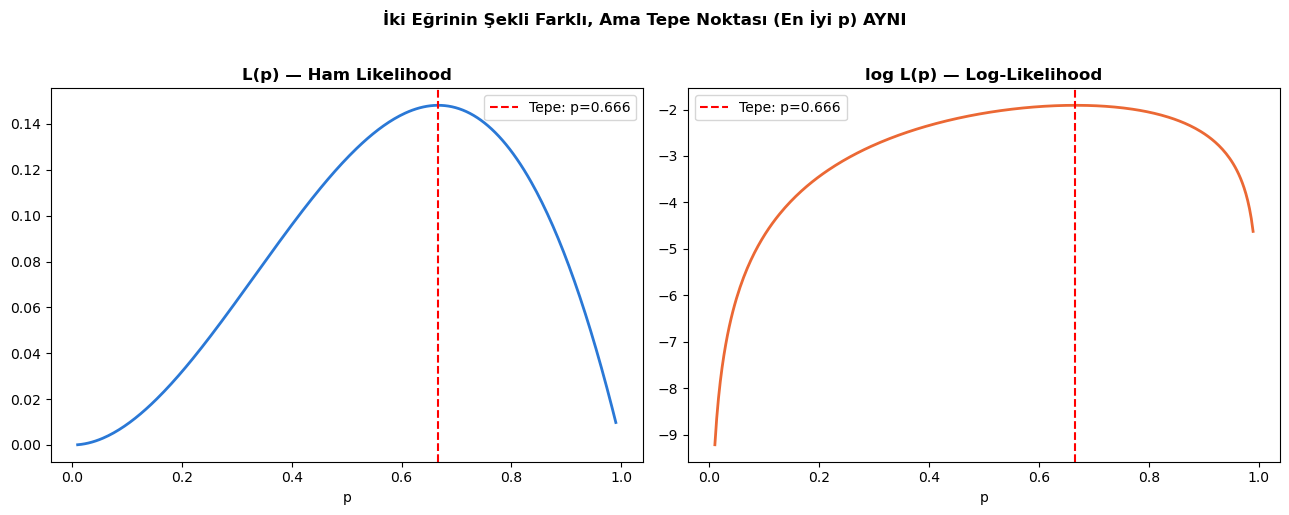

Ham likelihood'un tepe noktası: p = 0.6655
Log-likelihood'un tepe noktası: p = 0.6655
İkisi de 2/3 = 0.667'ye yakın çıkıyor - tam beklediğimiz gibi.


In [2]:
p_grid = np.linspace(0.01, 0.99, 300)

# Orijinal (kucuk) ornegimiz: 2 yazi, 1 tura
L_p = (p_grid**2) * (1-p_grid)
logL_p = 2*np.log(p_grid) + 1*np.log(1-p_grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(p_grid, L_p, color='#2a78d6', linewidth=2)
axes[0].axvline(p_grid[np.argmax(L_p)], color='red', linestyle='--', label=f'Tepe: p={p_grid[np.argmax(L_p)]:.3f}')
axes[0].set_title('L(p) — Ham Likelihood', fontweight='bold')
axes[0].set_xlabel('p'); axes[0].legend()

axes[1].plot(p_grid, logL_p, color='#eb6834', linewidth=2)
axes[1].axvline(p_grid[np.argmax(logL_p)], color='red', linestyle='--', label=f'Tepe: p={p_grid[np.argmax(logL_p)]:.3f}')
axes[1].set_title('log L(p) — Log-Likelihood', fontweight='bold')
axes[1].set_xlabel('p'); axes[1].legend()

plt.suptitle('İki Eğrinin Şekli Farklı, Ama Tepe Noktası (En İyi p) AYNI', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Ham likelihood'un tepe noktası: p = {p_grid[np.argmax(L_p)]:.4f}")
print(f"Log-likelihood'un tepe noktası: p = {p_grid[np.argmax(logL_p)]:.4f}")
print("İkisi de 2/3 = 0.667'ye yakın çıkıyor - tam beklediğimiz gibi.")

---
## 4 · MLE Türetimi: Kalkülüsle Genel Formülü Bulma

Yukarıda sayılarla "en iyi p, 0.67 civarı" dediğimiz şeyi, şimdi **genel bir formül** haline
getireceğiz — böylece her seferinde tek tek sayı denemek zorunda kalmayacağız.

**Adım 1:** $n$ deneme, $k$ tanesi başarı (yazı) olsun. Log-likelihood:
$$\ell(p) = k\log(p) + (n-k)\log(1-p)$$

**Adım 2:** Bir fonksiyonun **tepe noktasında türevi sıfırdır** (Bu, "maksimum/minimum bulma" işleminin temel prensibi). $\ell(p)$'yi $p$'ye göre türetelim:
$$\frac{d\ell}{dp} = \frac{k}{p} - \frac{n-k}{1-p}$$

**Adım 3:** Bu türevi sıfıra eşitleyip $p$ için çözelim:
$$\frac{k}{p} = \frac{n-k}{1-p} \quad\Rightarrow\quad k(1-p) = p(n-k) \quad\Rightarrow\quad k = np$$

$$\boxed{\hat{p}_{MLE} = \frac{k}{n}}$$

**Sonuç son derece sezgisel:** MLE tahmini, sadece **gözlemlenen oranın kendisi**! Bizim
örneğimizde $k=2$, $n=3$, yani $\hat{p}_{MLE} = 2/3 \approx 0.667$ — yukarıdaki sayısal
tabloda bulduğumuz "en iyi p" ile birebir aynı, ama artık formülle, tek işlemde bulduk.

---
## 5 · MLE'nin İkinci Örneği: Normal Dağılımın Parametreleri

Şimdi kesikli (Bernoulli) değil, **sürekli** bir değişken için MLE türetelim — çünkü
`insurance.csv`'deki `charges` (sigorta harcaması) gibi sürekli verilerde bu formülü kullanacağız.

$X_1,\dots,X_n \sim N(\mu,\sigma^2)$ olsun (bağımsız gözlemler). Log-likelihood:
$$\ell(\mu,\sigma^2) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2$$

$\mu$'ye göre türev alıp sıfıra eşitlersek (detayları atlıyoruz, aynı "türev al, sıfıra eşitle,
çöz" tarifi):
$$\boxed{\hat{\mu}_{MLE} = \bar{x} = \frac{1}{n}\sum x_i} \qquad \boxed{\hat{\sigma}^2_{MLE} = \frac{1}{n}\sum (x_i-\bar{x})^2}$$

**Sezgisi yine çok basit:** Normal dağılımın ortalamasının MLE tahmini, sadece **örneklem
ortalaması**; varyansının MLE tahmini de **örneklem varyansı** (ama dikkat: $n-1$ değil $n$
ile bölünüyor — bu, MLE'nin "biraz yanlı/biased" olduğu bilinen bir noktadır, `ddof=0` ile
`np.var()`'da karşına çıkacak).

---
## 6 · MLE'nin Sınırlaması: Küçük Örneklemde Ne Olur?

Örneğimize dönelim: parayı sadece **1 kez** attık ve **yazı** geldi ($k=1, n=1$). MLE formülü
şunu söylüyor:
$$\hat{p}_{MLE} = \frac{1}{1} = 1.0$$

Yani MLE, "bu para %100 kesinlikle yazı getirir, asla tura gelmez" diyor! Tek bir atıştan bu
kadar kesin bir iddiada bulunmak mantıksız — **küçük örneklemde MLE aşırı öz-güvenli
(overconfident) davranıyor.** Gerçek hayatta çoğu paranın adil (p≈0.5) olduğunu *önceden*
biliyoruz ama MLE bu "önsel bilgiyi" hesaba katmıyor — sadece elindeki (çok az) veriye
körü körüne güveniyor.

**İşte tam burada MAP devreye giriyor:** ya elimizde önsel bir inanç varsa (örn. "çoğu para
adildir") ve bunu da hesaba katmak istiyorsak?

---
## 7 · MAP: Bayes Teoremini Hatırlama

07a'daki formülü hatırla:
$$\underbrace{P(p \mid \text{veri})}_{\text{Posterior}} \propto \underbrace{P(\text{veri} \mid p)}_{\text{Likelihood}} \times \underbrace{P(p)}_{\text{Prior}}$$

MLE sadece **Likelihood**'u maksimize ediyordu. MAP ise **Likelihood × Prior** çarpımını
(yani Posterior'u) maksimize ediyor:
$$\hat{p}_{MAP} = \arg\max_p \Big[ \log L(p) + \log P(p) \Big]$$

Yani MAP, MLE'nin **prior ile "dizginlenmiş"** hali. Prior'un ağırlığı ne kadar güçlüyse
(örn. "adil paraya çok güveniyorum"), MAP tahmini o kadar prior'a doğru çekilir; veri ne
kadar çoksa, MAP tahmini o kadar MLE'ye yaklaşır (07b'de gördüğümüz "çok veri prior'u
bastırır" kuralı burada da geçerli).

**Çok önemli bir özel durum:** Eğer prior **düz (uniform)** ise — yani "hiçbir p değerini
diğerinden daha olası görmüyorum" dersen — $\log P(p)$ sabit bir sayı olur ve maksimizasyonu
etkilemez. Bu durumda:
$$\boxed{\hat{p}_{MAP} = \hat{p}_{MLE} \quad (\text{prior düzken})}$$

Yani **MLE, MAP'in özel bir halidir** — "hiçbir önsel bilgim yok" prior'uyla MAP'i çözdüğünde MLE'yi elde edersin.

---
## 8 · MAP Türetimi: Aynı Madeni Para Örneği Üzerinden

07b'de Beta dağılımının Binomial ile eşlenik olduğunu ispatlamıştık. Şimdi bunu MAP bağlamında
tekrar kullanıyoruz: **Prior olarak $\text{Beta}(\alpha,\beta)$ seçersek**, posterior da bir
Beta dağılımı olur ve MAP tahmini (Beta dağılımının **modu**, yani tepe noktası) için kapalı-form
bir formül vardır:

$$\boxed{\hat{p}_{MAP} = \frac{k + \alpha - 1}{n + \alpha + \beta - 2}}$$

**Örneğimize uygulayalım** ($k=1, n=1$ tek atış, yazı geldi): "Çoğu para adildir" inancımızı
$\text{Beta}(10,10)$ ile ifade edelim (bu, $p=0.5$ civarında güçlü bir öncül inanç):

$$\hat{p}_{MAP} = \frac{1 + 10 - 1}{1 + 10 + 10 - 2} = \frac{10}{19} \approx 0.526$$

**Karşılaştır:** $\hat{p}_{MLE} = 1.0$ (aşırı iddialı, tek veriden) vs $\hat{p}_{MAP} \approx 0.526$
(makul, prior tarafından "sağduyuya" çekilmiş). Aşağıda bunu görsel olarak da doğrulayacağız.

MLE tahmini: 1.0000  (sadece 1 veri noktasından, aşırı iddialı)
MAP tahmini: 0.5263  (prior ile dengelenmiş, makul)


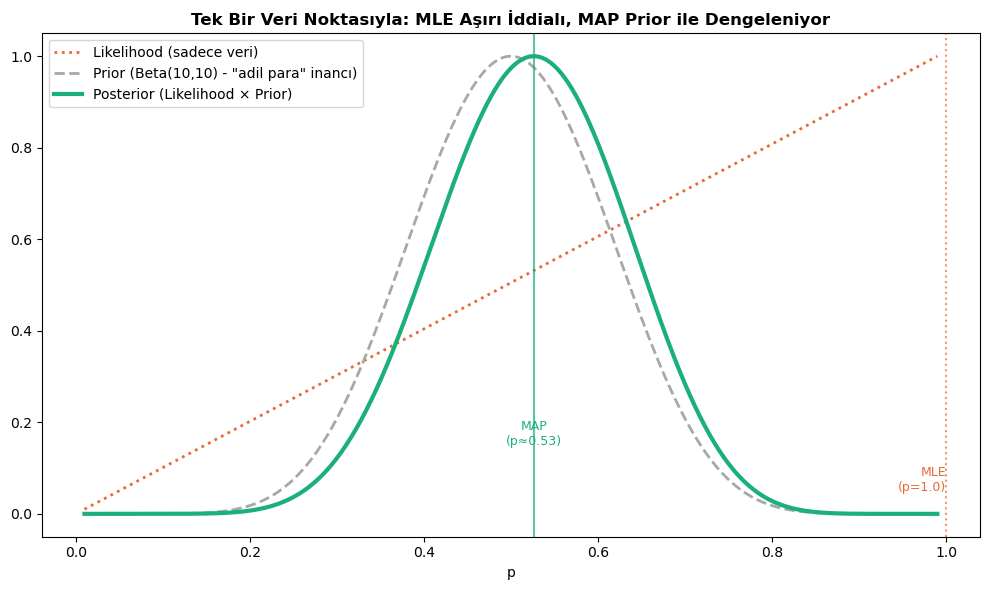

In [3]:
from scipy.optimize import minimize_scalar
import scipy.stats as stats

k, n = 1, 1  # tek atis, yazi geldi
alpha_prior, beta_prior = 10, 10  # "cogu para adildir" onsel inancimiz

# MLE: sadece likelihood'u maksimize et
mle_estimate = k / n

# MAP: likelihood x prior'u (yani posterior'u) maksimize et - kapali form
map_estimate = (k + alpha_prior - 1) / (n + alpha_prior + beta_prior - 2)

print(f"MLE tahmini: {mle_estimate:.4f}  (sadece 1 veri noktasından, aşırı iddialı)")
print(f"MAP tahmini: {map_estimate:.4f}  (prior ile dengelenmiş, makul)")

p_grid = np.linspace(0.01, 0.99, 500)
likelihood_curve = (p_grid**k) * ((1-p_grid)**(n-k))
likelihood_curve /= likelihood_curve.max()  # gorsellestirme icin normalize
prior_curve = stats.beta.pdf(p_grid, alpha_prior, beta_prior)
prior_curve /= prior_curve.max()
posterior_curve = stats.beta.pdf(p_grid, k+alpha_prior, (n-k)+beta_prior)
posterior_curve /= posterior_curve.max()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p_grid, likelihood_curve, ':', color='#eb6834', linewidth=2, label='Likelihood (sadece veri)')
ax.plot(p_grid, prior_curve, '--', color='#a8a8a8', linewidth=2, label='Prior (Beta(10,10) - "adil para" inancı)')
ax.plot(p_grid, posterior_curve, color='#1baf7a', linewidth=3, label='Posterior (Likelihood × Prior)')
ax.axvline(mle_estimate, color='#eb6834', linestyle=':', alpha=0.7)
ax.axvline(map_estimate, color='#1baf7a', linestyle='-', alpha=0.7)
ax.annotate('MLE\n(p=1.0)', xy=(mle_estimate, 0.05), fontsize=9, ha='right', color='#eb6834')
ax.annotate('MAP\n(p≈0.53)', xy=(map_estimate, 0.15), fontsize=9, ha='center', color='#1baf7a')
ax.set_title('Tek Bir Veri Noktasıyla: MLE Aşırı İddialı, MAP Prior ile Dengeleniyor', fontweight='bold')
ax.set_xlabel('p'); ax.legend()
plt.tight_layout()
plt.show()

---
## 9 · MLE vs MAP — Özet Karşılaştırma Tablosu

| | MLE | MAP |
|---|---|---|
| Maksimize edilen | $L(veri \mid \theta)$ | $L(veri\mid\theta) \times P(\theta)$ |
| Önsel bilgi kullanır mı? | Hayır | Evet (prior) |
| Küçük örneklemde davranış | Aşırı iddialı, overfit'e yatkın | Prior ile dengelenmiş, daha stabil |
| $n \to \infty$ iken | $\hat{\theta}_{MLE}$ | $\hat{\theta}_{MAP} \to \hat{\theta}_{MLE}$ (prior etkisi kaybolur) |
| Prior düzse (uniform) | — | $\hat{\theta}_{MAP} = \hat{\theta}_{MLE}$ (özel durum) |

**Kritik bağlantı — Regularizasyon:** Makine öğrenmesinde kullandığın Ridge/Lasso regresyon,
aslında birer MAP tahminidir!

- **Ridge Regresyon** = Normal (Gauss) prior ile MAP — katsayıların büyük olmasını "cezalandırır"
  çünkü Gauss dağılımı büyük değerlere düşük olasılık verir.
- **Lasso Regresyon** = Laplace prior ile MAP — katsayıları tam olarak sıfıra iter (feature
  seçimi yapar), çünkü Laplace dağılımının sivri tepesi sıfır civarında yoğunlaşır.

Bunu Python bölümünde sayısal olarak da doğrulayacağız — Ridge'in kapalı-form çözümüyle
elle hesapladığımız MAP formülünün birebir örtüştüğünü göreceksin.

---
# 🐍 Python Uygulaması

5 adımda ilerleyeceğiz:
1. **MLE Adım Adım (Bernoulli)** — Sigorta verisinde sigara içme oranını hem formülle hem sayısal optimizasyonla bulma
2. **MLE (Normal Dağılım)** — Sigorta harcamalarının ortalama/varyansını tahmin etme, 2D log-likelihood yüzeyi
3. **MLE = OLS Bağlantısı** — Lineer regresyonun aslında bir MLE problemi olduğunu kanıtlama
4. **MAP Adım Adım (Beta-Binomial)** — Airbnb'de küçük örneklemli bir mahallede MAP'in MLE'yi nasıl dengelediğini görme
5. **MAP = Ridge Regresyon Bağlantısı** — Regularizasyonun Bayesyen yorumunu sayısal olarak doğrulama

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize, minimize_scalar

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🚬 Python 1 — MLE Adım Adım: Sigara İçme Oranı

**Ne yapıyoruz?**  
`insurance.csv`'de kaç kişinin sigara içtiğini biliyoruz — bu Bernoulli/Binomial bir değişken.
Önce **kapalı-form formülü** ($\hat{p}=k/n$) uyguluyoruz, sonra aynı sonucu `scipy.optimize`
ile **sayısal olarak** (log-likelihood'u maksimize ederek) bulup ikisinin örtüştüğünü doğruluyoruz.

Veri: 1338 kişi

Kapalı-form MLE: p̂ = k/n = 274/1338 = 0.2048
Sayısal (optimize) MLE: p̂ = 0.2048

İki yöntem birebir örtüşüyor mü? EVET ✓


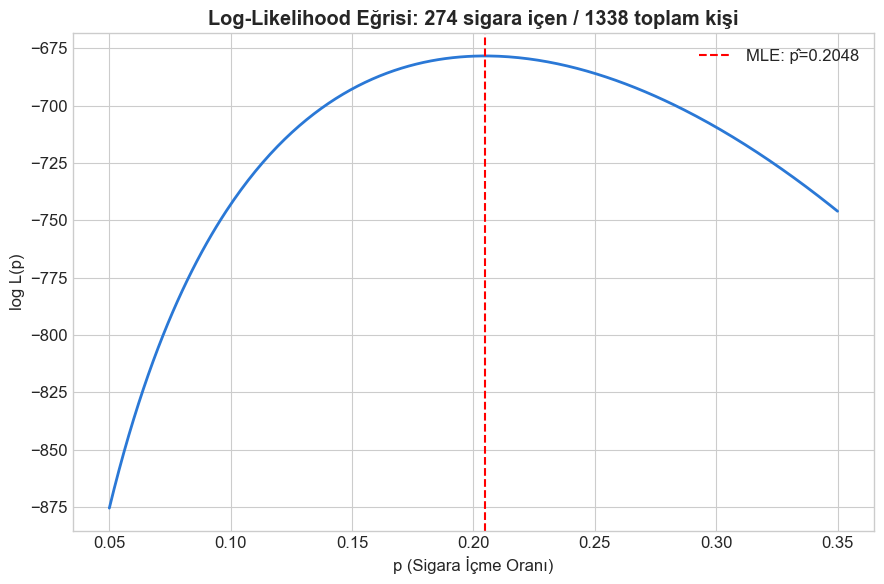

In [5]:
insurance = pd.read_csv('data/insurance.csv')
print(f"Veri: {insurance.shape[0]} kişi")

smoker_binary = (insurance['smoker'] == 'yes').astype(int)
k = smoker_binary.sum()
n = len(smoker_binary)

# ===== KAPALI-FORM MLE =====
p_mle_formula = k / n
print(f"\nKapalı-form MLE: p̂ = k/n = {k}/{n} = {p_mle_formula:.4f}")

# ===== SAYISAL (NUMERIK) MLE =====
def negatif_log_likelihood(p, k, n):
    # optimize.minimize hep MINIMIZE eder, o yuzden log-likelihood'un NEGATIFINI aliyoruz
    # (negatifi minimize etmek = orijinali maksimize etmek)
    if p <= 0 or p >= 1:
        return np.inf
    return -(k * np.log(p) + (n - k) * np.log(1 - p))

sonuc = minimize_scalar(negatif_log_likelihood, bounds=(0.001, 0.999), method='bounded', args=(k, n))
p_mle_numeric = sonuc.x
print(f"Sayısal (optimize) MLE: p̂ = {p_mle_numeric:.4f}")
print(f"\nİki yöntem birebir örtüşüyor mü? {'EVET ✓' if abs(p_mle_formula - p_mle_numeric) < 1e-4 else 'HAYIR ✗'}")

# Log-likelihood egrisini gorsellestir
p_grid = np.linspace(0.05, 0.35, 300)
logL = k * np.log(p_grid) + (n - k) * np.log(1 - p_grid)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(p_grid, logL, color='#2a78d6', linewidth=2)
ax.axvline(p_mle_formula, color='red', linestyle='--', label=f'MLE: p̂={p_mle_formula:.4f}')
ax.set_title(f'Log-Likelihood Eğrisi: {k} sigara içen / {n} toplam kişi', fontweight='bold')
ax.set_xlabel('p (Sigara İçme Oranı)'); ax.set_ylabel('log L(p)')
ax.legend()
plt.tight_layout()
plt.show()

---
### 💰 Python 2 — MLE (Normal Dağılım): Sigorta Harcaması Ortalaması

**Ne yapıyoruz?**  
`charges` sütunu sürekli bir değişken. Bölüm 5'teki formülleri ($\hat{\mu}=\bar{x}$,
$\hat{\sigma}^2$) uygulayıp, ayrıca $\mu$ ve $\sigma$'nun **her ikisini birden** değiştirerek
2 boyutlu bir log-likelihood "yüzeyi" çizeceğiz — MLE'nin bu yüzeyin **tepe noktası** olduğunu göreceksin.

MLE μ̂ (ortalama): 13270.42
MLE σ̂² (varyans, n ile bölünmüş): 146542766.49
MLE σ̂ (standart sapma): 12105.48


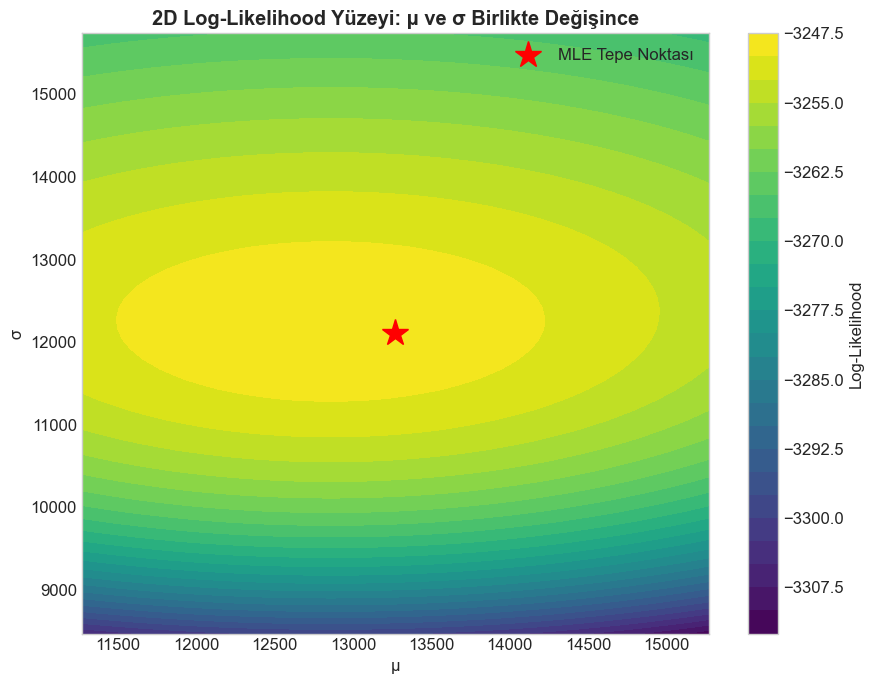


YORUM: Kırmızı yıldız (MLE), yüzeyin en 'sıcak' (en yüksek log-likelihood) noktasında -
tıpkı bir dağın zirvesini bulmak gibi, MLE bu 2 boyutlu yüzeyde zirveyi arıyor.


In [6]:
charges = insurance['charges'].values

# ===== KAPALI-FORM MLE =====
mu_mle = charges.mean()
sigma2_mle = charges.var(ddof=0)  # DIKKAT: ddof=0, yani n ile bolme (MLE budur, n-1 degil)

print(f"MLE μ̂ (ortalama): {mu_mle:.2f}")
print(f"MLE σ̂² (varyans, n ile bölünmüş): {sigma2_mle:.2f}")
print(f"MLE σ̂ (standart sapma): {np.sqrt(sigma2_mle):.2f}")

# ===== 2D LOG-LIKELIHOOD YUZEYI =====
mu_range = np.linspace(mu_mle - 2000, mu_mle + 2000, 60) # mu etrafinda +/- 2000 arasi 60 nokta
sigma_range = np.linspace(np.sqrt(sigma2_mle) * 0.7, np.sqrt(sigma2_mle) * 1.3, 60) # sigma etrafinda +/- %30 arasi 60 nokta
MU, SIGMA = np.meshgrid(mu_range, sigma_range) 

def log_likelihood_normal(mu, sigma, data):
    n = len(data)
    return -n/2 * np.log(2*np.pi*sigma**2) - np.sum((data - mu)**2) / (2*sigma**2)

# Hesaplama hizli olsun diye bir alt-orneklem kullanalim (sonuc degismez, sadece hiz icin)
rng = np.random.default_rng(0)
alt_ornek = rng.choice(charges, size=300, replace=False)

Z = np.zeros_like(MU)
for i in range(MU.shape[0]):
    for j in range(MU.shape[1]):
        Z[i, j] = log_likelihood_normal(MU[i, j], SIGMA[i, j], alt_ornek)

fig, ax = plt.subplots(figsize=(9, 7))
c = ax.contourf(MU, SIGMA, Z, levels=30, cmap='viridis')
ax.plot(mu_mle, np.sqrt(sigma2_mle), 'r*', markersize=20, label='MLE Tepe Noktası')
plt.colorbar(c, label='Log-Likelihood')
ax.set_title('2D Log-Likelihood Yüzeyi: μ ve σ Birlikte Değişince', fontweight='bold')
ax.set_xlabel('μ'); ax.set_ylabel('σ')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: Kırmızı yıldız (MLE), yüzeyin en 'sıcak' (en yüksek log-likelihood) noktasında -")
print("tıpkı bir dağın zirvesini bulmak gibi, MLE bu 2 boyutlu yüzeyde zirveyi arıyor.")

---
### 📈 Python 3 — MLE = OLS Bağlantısı: Lineer Regresyon Aslında Bir MLE Problemi

**Ne yapıyoruz?**  
"Hataların Normal dağıldığı" varsayımı altında, lineer regresyon katsayılarını **MLE ile**
(log-likelihood'u maksimize ederek) buluyoruz — sonra `sklearn.LinearRegression`'ın (OLS) verdiği
sonuçla karşılaştırıp **birebir aynı çıktığını** kanıtlıyoruz.

In [8]:
from sklearn.linear_model import LinearRegression

X = insurance[['age', 'bmi']].values
y = insurance['charges'].values

# ===== SKLEARN (OLS) =====
ols = LinearRegression()
ols.fit(X, y)
print(f"OLS (sklearn) katsayıları: intercept={ols.intercept_:.2f}, age={ols.coef_[0]:.2f}, bmi={ols.coef_[1]:.2f}")

# ===== MLE (dogrudan log-likelihood maksimize ederek) =====
# ONEMLI TEKNIK NOT: sigma'yi da beraber optimize etmeye calismak yuzeyi sayisal olarak
# zorlastirir (kotu yakinsama riski). Bunun yerine "profil likelihood" numarasini kullaniyoruz:
# sabit bir beta icin sigma_hat^2'nin kapali formu zaten mean(residuals^2)'dir (Bolum 5'teki
# Normal MLE formulunun ta kendisi) - o yuzden sigma'yi optimizasyondan CIKARIP, sadece
# katsayilar (beta) uzerinde arama yapiyoruz. Bu hem daha hizli hem cok daha guvenilir.
def negatif_profil_log_likelihood(beta, X, y):
    y_pred = beta[0] + beta[1]*X[:, 0] + beta[2]*X[:, 1]
    resid = y - y_pred
    n = len(y)
    sigma2_hat = np.mean(resid**2)  # kapali form: Bolum 5'teki sigma_hat^2 formulu
    if sigma2_hat <= 0:
        return np.inf
    log_likelihood = -n/2 * np.log(2*np.pi*sigma2_hat) - n/2
    return -log_likelihood

baslangic = [0, 0, 0]
sonuc = minimize(negatif_profil_log_likelihood, baslangic, args=(X, y), method='Nelder-Mead',
                  options={'maxiter': 20000, 'xatol': 1e-8, 'fatol': 1e-8})
intercept_mle, b_age_mle, b_bmi_mle = sonuc.x

print(f"MLE (elle) katsayıları:      intercept={intercept_mle:.2f}, age={b_age_mle:.2f}, bmi={b_bmi_mle:.2f}")
print(f"Optimizasyon başarılı mı: {sonuc.success}")
print(f"\nİki yöntem ne kadar örtüşüyor?")
print(f"  intercept farkı: {abs(ols.intercept_ - intercept_mle):.4f}")
print(f"  age katsayısı farkı: {abs(ols.coef_[0] - b_age_mle):.4f}")
print(f"  bmi katsayısı farkı: {abs(ols.coef_[1] - b_bmi_mle):.4f}")
print("\nYORUM: Farklar neredeyse sıfır - bu, OLS'in (En Küçük Kareler) aslında 'hatalar Normal")
print("dağılıyor' varsayımı altında bir MLE problemi olduğunu KANITLIYOR.")
print("'OLS' ile buradaki 'MLE' matematiksel olarak AYNI ŞEY.")

OLS (sklearn) katsayıları: intercept=-6424.80, age=241.93, bmi=332.97
MLE (elle) katsayıları:      intercept=-6424.80, age=241.93, bmi=332.97
Optimizasyon başarılı mı: True

İki yöntem ne kadar örtüşüyor?
  intercept farkı: 0.0027
  age katsayısı farkı: 0.0000
  bmi katsayısı farkı: 0.0001

YORUM: Farklar neredeyse sıfır - bu, OLS'in (En Küçük Kareler) aslında 'hatalar Normal
dağılıyor' varsayımı altında bir MLE problemi olduğunu KANITLIYOR.
'OLS' ile buradaki 'MLE' matematiksel olarak AYNI ŞEY.


---
### 🏠 Python 4 — MAP Adım Adım: Airbnb'de Küçük Örneklemli Bir Mahalle

**Ne yapıyoruz?**  
NYC'de bazı mahallelerde çok az sayıda Airbnb ilanı var — bu **küçük örneklem** durumu tam
olarak Bölüm 6'daki "MLE aşırı iddialı olur" senaryosunu canlandırıyor. "Private room" oranını,
hem MLE hem MAP ile tahmin edip karşılaştıracağız.

Veri: 48895 ilan

Seçilen mahalle: 'Mariners Harbor' (sadece 8 ilan var - küçük örneklem!)
Bunların 5 tanesi 'Private room'

NYC geneli 'Private room' oranı (prior için kullanılan): 0.4566
MLE (sadece bu mahalleden): 0.6250
MAP (genel eğilimle dengelenmiş): 0.5051


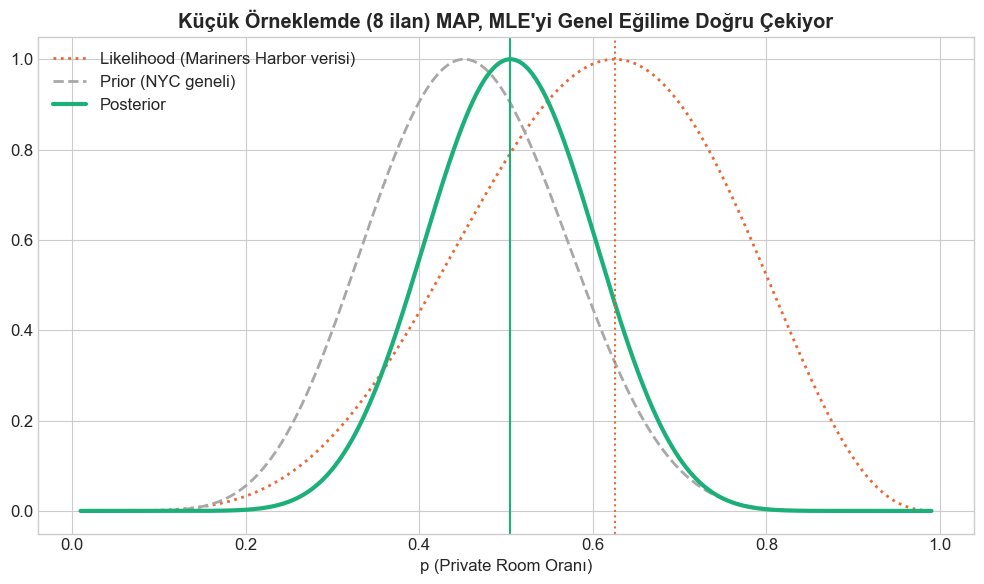

In [9]:
airbnb = pd.read_csv('data/AB_NYC_2019.csv')
print(f"Veri: {airbnb.shape[0]} ilan")

# En az ilana sahip (kucuk ornekli) birkac mahalleyi bulalim
mahalle_sayilari = airbnb['neighbourhood'].value_counts()
kucuk_mahalleler = mahalle_sayilari[(mahalle_sayilari >= 3) & (mahalle_sayilari <= 8)]
secilen_mahalle = kucuk_mahalleler.index[0]

alt_veri = airbnb[airbnb['neighbourhood'] == secilen_mahalle]
n_local = len(alt_veri)
k_local = (alt_veri['room_type'] == 'Private room').sum()

print(f"\nSeçilen mahalle: '{secilen_mahalle}' (sadece {n_local} ilan var - küçük örneklem!)")
print(f"Bunların {k_local} tanesi 'Private room'")

# MLE
p_mle_local = k_local / n_local

# MAP: New York genelindeki oranı prior olarak kullanalim (bilgi tasiyan bir prior)
genel_oran = (airbnb['room_type'] == 'Private room').mean()
# Bu genel orani bir Beta prior'a cevirelim (guclu bir prior, "genel egilimi biliyoruz" diyoruz)
prior_agirlik = 20  # ne kadar "guclu" bir onsel inanc oldugunu belirler
alpha_prior_l = genel_oran * prior_agirlik
beta_prior_l = (1 - genel_oran) * prior_agirlik

p_map_local = (k_local + alpha_prior_l - 1) / (n_local + alpha_prior_l + beta_prior_l - 2)

print(f"\nNYC geneli 'Private room' oranı (prior için kullanılan): {genel_oran:.4f}")
print(f"MLE (sadece bu mahalleden): {p_mle_local:.4f}")
print(f"MAP (genel eğilimle dengelenmiş): {p_map_local:.4f}")

p_grid = np.linspace(0.01, 0.99, 500)
likelihood_l = (p_grid**k_local) * ((1-p_grid)**(n_local-k_local))
likelihood_l /= likelihood_l.max()
prior_l = stats.beta.pdf(p_grid, alpha_prior_l, beta_prior_l)
prior_l /= prior_l.max()
posterior_l = stats.beta.pdf(p_grid, k_local+alpha_prior_l, (n_local-k_local)+beta_prior_l)
posterior_l /= posterior_l.max()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p_grid, likelihood_l, ':', color='#eb6834', linewidth=2, label=f'Likelihood ({secilen_mahalle} verisi)')
ax.plot(p_grid, prior_l, '--', color='#a8a8a8', linewidth=2, label='Prior (NYC geneli)')
ax.plot(p_grid, posterior_l, color='#1baf7a', linewidth=3, label='Posterior')
ax.axvline(p_mle_local, color='#eb6834', linestyle=':')
ax.axvline(p_map_local, color='#1baf7a')
ax.set_title(f"Küçük Örneklemde ({n_local} ilan) MAP, MLE'yi Genel Eğilime Doğru Çekiyor", fontweight='bold')
ax.set_xlabel('p (Private Room Oranı)'); ax.legend()
plt.tight_layout()
plt.show()

---
### 🎯 Python 5 — MAP = Ridge Regresyon Bağlantısı

**Ne yapıyoruz?**  
Bölüm 9'da "Ridge regresyon = Gauss prior ile MAP" dedik. Bunu sayısal olarak kanıtlayacağız:
`sklearn.Ridge`'in verdiği katsayılarla, Gauss prior'lu MAP'in **kapalı-form formülünün**
verdiği katsayıları karşılaştırıp birebir örtüştüklerini göreceğiz.

sklearn Ridge katsayıları: [3281.86141691 1968.82501519]
Kapalı-form MAP katsayıları:  [3281.86141691 1968.82501519]

Fark: [9.09494702e-13 2.27373675e-13]
İki yöntem örtüşüyor mü? EVET ✓


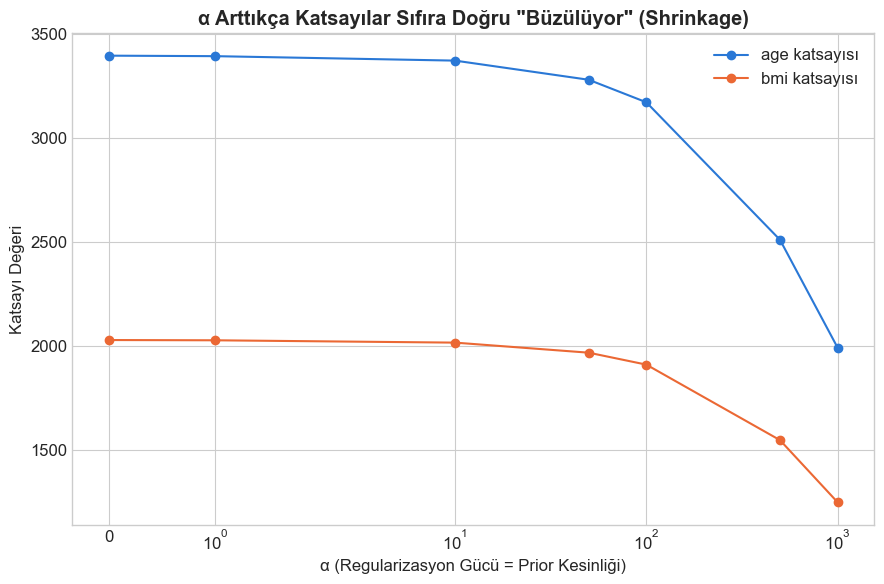


YORUM: α=0 iken Ridge, sıradan OLS'e (dolayısıyla MLE'ye) eşit. α büyüdükçe (prior
'katsayılar küçük olmalı' konusunda daha 'kesin/güçlü' hale geldikçe), katsayılar sıfıra
yaklaşıyor. Bu tam olarak 07b'deki 'prior kesinse posterior prior'a yakın kalır' kuralı.


In [10]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

X_r = insurance[['age', 'bmi']].values
y_r = insurance['charges'].values

# Standardize edelim (Ridge'in regularizasyonu olceklemeye duyarlidir)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_r)
y_mean = y_r.mean()
y_centered = y_r - y_mean

alpha_ridge = 50.0  # sklearn'in regularizasyon gucu parametresi

# ===== SKLEARN RIDGE =====
ridge = Ridge(alpha=alpha_ridge, fit_intercept=False)
ridge.fit(X_scaled, y_centered)
print(f"sklearn Ridge katsayıları: {ridge.coef_}")

# ===== KAPALI-FORM MAP (Ridge'in matematiksel esdegeri) =====
# Ridge/MAP kapali form: beta_hat = (X'X + alpha*I)^-1 X'y
n_features = X_scaled.shape[1]
XtX = X_scaled.T @ X_scaled
Xty = X_scaled.T @ y_centered
beta_map = np.linalg.solve(XtX + alpha_ridge * np.eye(n_features), Xty)

print(f"Kapalı-form MAP katsayıları:  {beta_map}")
print(f"\nFark: {np.abs(ridge.coef_ - beta_map)}")
print("İki yöntem örtüşüyor mü?", "EVET ✓" if np.allclose(ridge.coef_, beta_map, atol=1e-6) else "HAYIR ✗")

# alpha (regularizasyon gucu = prior'un "kesinligi") arttikca katsayilarin nasil kuculdugu
alphas = [0, 1, 10, 50, 100, 500, 1000]
katsayilar = []
for a in alphas:
    b = np.linalg.solve(XtX + a * np.eye(n_features), Xty)
    katsayilar.append(b)
katsayilar = np.array(katsayilar)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(alphas, katsayilar[:, 0], 'o-', color='#2a78d6', label='age katsayısı')
ax.plot(alphas, katsayilar[:, 1], 'o-', color='#eb6834', label='bmi katsayısı')
ax.set_xscale('symlog')
ax.set_xlabel('α (Regularizasyon Gücü = Prior Kesinliği)')
ax.set_ylabel('Katsayı Değeri')
ax.set_title('α Arttıkça Katsayılar Sıfıra Doğru "Büzülüyor" (Shrinkage)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: α=0 iken Ridge, sıradan OLS'e (dolayısıyla MLE'ye) eşit. α büyüdükçe (prior")
print("'katsayılar küçük olmalı' konusunda daha 'kesin/güçlü' hale geldikçe), katsayılar sıfıra")
print("yaklaşıyor. Bu tam olarak 07b'deki 'prior kesinse posterior prior'a yakın kalır' kuralı.")

---
# 📊 R Uygulaması

Python'da işlediğimiz üç ana konuyu (Normal MLE, Bernoulli MLE, Beta-Binomial MAP) R'da
tekrarlıyoruz — `MASS::fitdistr()` fonksiyonu, R'ın "otomatik MLE bulucusu".

In [11]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 💰 R 1 — MLE: `fitdistr()` ile Otomatik Dağılım Uydurma

**Yeni R kavramı:** `MASS::fitdistr(veri, "normal")` — elle türev almana gerek kalmadan,
R'ın kendisi log-likelihood'u maksimize edip $\hat{\mu}$ ve $\hat{\sigma}$'yı buluyor.
Python'da elle yaptığımız işi R'da tek satıra indiriyoruz.

      mean          sd    
  13270.4223   12105.4850 
 (  330.9437) (  234.0125)

Karşılaştırma - elle hesaplanan MLE:
mu_hat (mean): 13270.42 
sigma_hat (population sd, n ile): 12105.48 


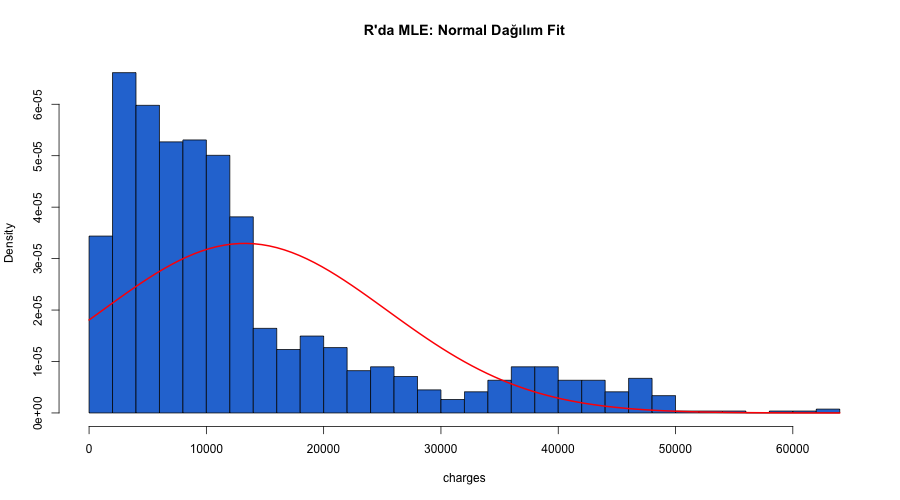

In [22]:
%%R -i insurance -w 900 -h 500

library(MASS)

fit_sonuc <- fitdistr(insurance$charges, "normal")
print(fit_sonuc)

cat("\nKarşılaştırma - elle hesaplanan MLE:\n")
cat("mu_hat (mean):", mean(insurance$charges), "\n")
cat("sigma_hat (population sd, n ile):", sqrt(mean((insurance$charges - mean(insurance$charges))^2)), "\n")

hist(insurance$charges, breaks=40, freq=FALSE, col="#2a78d6", 
     main="R'da MLE: Normal Dağılım Fit", xlab="charges")
curve(dnorm(x, fit_sonuc$estimate["mean"], fit_sonuc$estimate["sd"]), col="red", lwd=2, add=TRUE)

---
### 🚬 R 2 — MLE (Bernoulli): Log-Likelihood'u Elle Optimize Etme

**Yeni R kavramı:** `optim()` — Python'daki `scipy.optimize.minimize()`'ın R karşılığı.
Elle bir negatif log-likelihood fonksiyonu yazıp R'a "bunu minimize et" diyoruz.

In [24]:
%%R -i insurance

smoker_bin <- ifelse(insurance$smoker == "yes", 1, 0)
k <- sum(smoker_bin); n <- length(smoker_bin)

# Kapali form
p_mle_formula <- k / n
cat("Kapalı-form MLE: p̂ =", p_mle_formula, "\n")

# optim() ile sayisal MLE
negatif_log_likelihood <- function(p, k, n) {
  if (p <= 0 || p >= 1) return(Inf)
  -(k * log(p) + (n - k) * log(1 - p))
}

sonuc <- optim(par = 0.5, fn = negatif_log_likelihood, k = k, n = n, method = "Brent", lower = 0.001, upper = 0.999)
cat("optim() ile sayısal MLE: p̂ =", sonuc$par, "\n")
cat("İki yöntem farkı:", abs(p_mle_formula - sonuc$par), "\n")

Kapalı-form MLE: p̂ = 0.2047833 
optim() ile sayısal MLE: p̂ = 0.2047833 
İki yöntem farkı: 1.565853e-09 


---
### 🏠 R 3 — MAP: Küçük Örneklemli Airbnb Mahallesi

**Yeni R kavramı yok** — Python 4'teki mantığın R'da elle tekrarı, kapalı-form MAP formülünü
doğrudan uyguluyoruz.

Seçilen mahalle: Arden Heights - n = 4 , k = 1 
MLE: 0.25  | MAP: 0.4151  | Genel Oran (Prior): 0.4566 


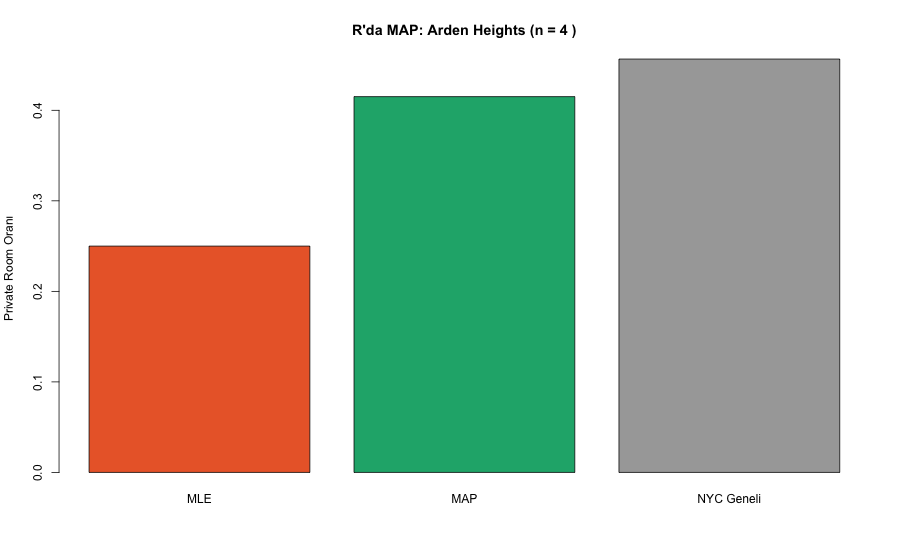

In [25]:
%%R -i airbnb -w 900 -h 550

mahalle_sayilari <- table(airbnb$neighbourhood)
kucuk_mahalleler <- names(mahalle_sayilari[mahalle_sayilari >= 3 & mahalle_sayilari <= 8])
secilen <- kucuk_mahalleler[1]

alt_veri <- airbnb[airbnb$neighbourhood == secilen, ]
n_local <- nrow(alt_veri)
k_local <- sum(alt_veri$room_type == "Private room")

cat("Seçilen mahalle:", secilen, "- n =", n_local, ", k =", k_local, "\n")

p_mle_local <- k_local / n_local

genel_oran <- mean(airbnb$room_type == "Private room")
prior_agirlik <- 20
alpha_p <- genel_oran * prior_agirlik
beta_p <- (1 - genel_oran) * prior_agirlik

p_map_local <- (k_local + alpha_p - 1) / (n_local + alpha_p + beta_p - 2)

cat("MLE:", round(p_mle_local, 4), " | MAP:", round(p_map_local, 4), " | Genel Oran (Prior):", round(genel_oran, 4), "\n")

barplot(c(MLE = p_mle_local, MAP = p_map_local, `NYC Geneli` = genel_oran),
        col = c("#eb6834", "#1baf7a", "#a8a8a8"),
        main = paste("R'da MAP:", secilen, "(n =", n_local, ")"),
        ylab = "Private Room Oranı")

---
# 🗄️ SQL Uygulaması (DuckDB)

Bazı MLE tahminleri SQL'de doğrudan yerleşik fonksiyonlarla hesaplanabiliyor — `AVG()` aslında
Normal dağılımın $\hat{\mu}_{MLE}$'si, `VAR_POP()` da $\hat{\sigma}^2_{MLE}$'si (dikkat:
`VAR_SAMP()` değil, çünkü MLE $n$ ile bölüyor, $n-1$ ile değil).

In [26]:
import duckdb
con = duckdb.connect()
con.register('insurance_tbl', insurance)
con.register('airbnb_tbl', airbnb)
print('DuckDB hazır ✓')

DuckDB hazır ✓


---
### 💰 SQL 1 — Normal MLE: `AVG()` ve `VAR_POP()` Aslında MLE'dir

**Ne yapıyoruz?**  
Bölgeye (`region`) göre gruplanmış ortalama ve varyans hesaplıyoruz — her satır, o bölge için
ayrı bir MLE tahmini.

In [27]:
sql_mle_normal = con.execute("""
    SELECT
        region,
        COUNT(*) AS n,
        ROUND(AVG(charges), 2) AS mu_hat_MLE,
        ROUND(VAR_POP(charges), 2) AS sigma2_hat_MLE,
        ROUND(STDDEV_POP(charges), 2) AS sigma_hat_MLE
    FROM insurance_tbl
    GROUP BY region
    ORDER BY mu_hat_MLE DESC
""").df()

print(sql_mle_normal.to_string(index=False))
print("\nDİKKAT: VAR_POP() kullandık (VAR_SAMP() değil) çünkü MLE tanımı gereği n ile bölüyor.")
print("Python'daki np.var(ddof=0) ile bu satırdaki değerler birebir örtüşmeli.")

   region   n  mu_hat_MLE  sigma2_hat_MLE  sigma_hat_MLE
southeast 364    14735.41    194655355.14       13951.89
northeast 324    13406.38    126302074.56       11238.42
northwest 325    12417.58    122218100.00       11055.23
southwest 325    12346.94    133157409.11       11539.39

DİKKAT: VAR_POP() kullandık (VAR_SAMP() değil) çünkü MLE tanımı gereği n ile bölüyor.
Python'daki np.var(ddof=0) ile bu satırdaki değerler birebir örtüşmeli.


---
### 🚬 SQL 2 — Bernoulli MLE: Bölgeye Göre Sigara İçme Oranı

**Ne yapıyoruz?**  
`AVG(CASE WHEN ...)` kalıbı, bir 0/1 değişkenin ortalamasını almak = doğrudan $\hat{p}_{MLE}$
hesaplamak demek (Bölüm 4'teki $\hat{p}=k/n$ formülünün SQL karşılığı).

In [28]:
sql_mle_bernoulli = con.execute("""
    SELECT
        region,
        COUNT(*) AS n,
        SUM(CASE WHEN smoker='yes' THEN 1 ELSE 0 END) AS k_sigara_icen,
        ROUND(AVG(CASE WHEN smoker='yes' THEN 1.0 ELSE 0.0 END), 4) AS p_hat_MLE
    FROM insurance_tbl
    GROUP BY region
    ORDER BY p_hat_MLE DESC
""").df()

print(sql_mle_bernoulli.to_string(index=False))
print("\np_hat_MLE sütunu, her bölge için AVG(0/1 değişken) = k/n formülünün doğrudan sonucu.")

   region   n  k_sigara_icen  p_hat_MLE
southeast 364           91.0     0.2500
northeast 324           67.0     0.2068
southwest 325           58.0     0.1785
northwest 325           58.0     0.1785

p_hat_MLE sütunu, her bölge için AVG(0/1 değişken) = k/n formülünün doğrudan sonucu.


---
### 🏠 SQL 3 — MAP: Oda Tipi Konjuge Güncellemesi (Mahalle Grubu Bazlı)

**Ne yapıyoruz?**  
`neighbourhood_group` (5 büyük NYC bölgesi) bazında, "Private room" oranı için MAP posterior
parametrelerini hesaplıyoruz — 07b'deki Beta-Binomial güncelleme kalıbının SQL'de tekrarı.

In [29]:
genel_oran_sql = con.execute("""
    SELECT AVG(CASE WHEN room_type='Private room' THEN 1.0 ELSE 0.0 END) AS genel_oran
    FROM airbnb_tbl
""").df()['genel_oran'][0]

alpha_prior_sql = genel_oran_sql * 20
beta_prior_sql = (1 - genel_oran_sql) * 20

sql_map = con.execute(f"""
    SELECT
        neighbourhood_group,
        COUNT(*) AS n,
        SUM(CASE WHEN room_type='Private room' THEN 1 ELSE 0 END) AS k,
        ROUND(AVG(CASE WHEN room_type='Private room' THEN 1.0 ELSE 0.0 END), 4) AS p_hat_MLE,
        ROUND(
            (SUM(CASE WHEN room_type='Private room' THEN 1 ELSE 0 END) + {alpha_prior_sql} - 1) /
            (COUNT(*) + {alpha_prior_sql} + {beta_prior_sql} - 2),
            4
        ) AS p_hat_MAP
    FROM airbnb_tbl
    GROUP BY neighbourhood_group
    ORDER BY n
""").df()

print(f"Prior (NYC geneli): {genel_oran_sql:.4f} -> Beta({alpha_prior_sql:.2f}, {beta_prior_sql:.2f})\n")
print(sql_map.to_string(index=False))
print("\nYORUM: n küçük olan gruplarda (varsa) p_hat_MLE ile p_hat_MAP arasındaki fark daha")
print("belirgin olmalı - n büyüdükçe iki sütun birbirine yaklaşır.")

Prior (NYC geneli): 0.4566 -> Beta(9.13, 10.87)

neighbourhood_group     n       k  p_hat_MLE  p_hat_MAP
      Staten Island   373   188.0     0.5040     0.5016
              Bronx  1091   652.0     0.5976     0.5952
             Queens  5666  3372.0     0.5951     0.5947
           Brooklyn 20104 10132.0     0.5040     0.5039
          Manhattan 21661  7982.0     0.3685     0.3686

YORUM: n küçük olan gruplarda (varsa) p_hat_MLE ile p_hat_MAP arasındaki fark daha
belirgin olmalı - n büyüdükçe iki sütun birbirine yaklaşır.


---
## ✏️ Egzersizler

### **E1 (Python) - Kanser Hayatta Kalma Exp MLE** 
`global_cancer_patients_2015_2024.csv`'de `Survival_Years` (hayatta kalma
süresi) sütunu için Exponential MLE uygula: $\hat{\lambda}_{MLE} = 1/\bar{x}$ formülünü kullan
(Exponential dağılımın MLE'sinin bu kadar basit olduğunu Bölüm 5'teki türetim mantığıyla
kendin de türetebilirsin — Normal yerine Exponential PDF'i kullan). Fit kalitesini, gerçek
histogram üzerine `scipy.stats.expon.pdf()` çizerek görsel olarak kontrol et.


 ==== Egzersiz 1 - Kanser Hastalığı için Exponential MLE Uygulaması ====
Örneklem Ortalaması (x_bar): 5.0065
Üstel Dağılım Tahmini (Lambda MLE): 0.1997

YORUM: Üstel dağılımın MLE'si, örneklem ortalamasının tersidir. Bu, üstel dağılımın özelliğidir ve MLE'nin kapalı form çözümüdür. Bu tahmin, gözlemlenen veriye en iyi uyan lambda değerini temsil eder.


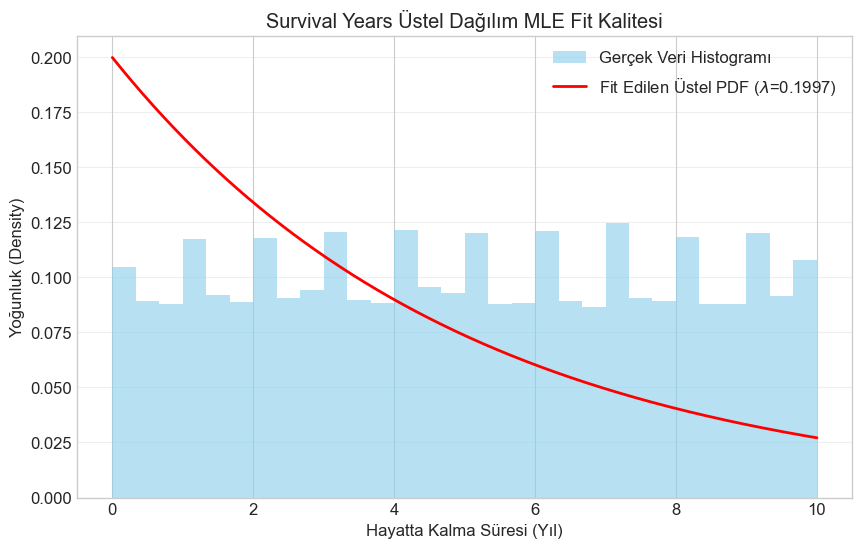

In [35]:
print("\n ==== Egzersiz 1 - Kanser Hastalığı için Exponential MLE Uygulaması ====")

cancer = pd.read_csv('data/global_cancer_patients_2015_2024.csv')

survival_Years = cancer['Survival_Years'].values

x_bar = survival_Years.mean() # MLE için kapalı form: lambda_hat = 1 / x_bar
lambda_hat_mle = 1 / x_bar

print(f"Örneklem Ortalaması (x_bar): {x_bar:.4f}")
print(f"Üstel Dağılım Tahmini (Lambda MLE): {lambda_hat_mle:.4f}")

print("\nYORUM: Üstel dağılımın MLE'si, örneklem ortalamasının tersidir. Bu, üstel dağılımın özelliğidir ve MLE'nin kapalı form çözümüdür. Bu tahmin, gözlemlenen veriye en iyi uyan lambda değerini temsil eder.")

plt.figure(figsize=(10, 6))
count, bins, ignored = plt.hist(survival_Years, bins=30, density=True, alpha=0.6, color='skyblue', label='Gerçek Veri Histogramı')

# scipy.stats.expon için scale = 1 / lambda parametresi kullanılır
x = np.linspace(0, survival_Years.max(), 1000)
pdf_fitted = stats.expon.pdf(x, scale=1/lambda_hat_mle)

plt.plot(x, pdf_fitted, 'r-', linewidth=2, label=f'Fit Edilen Üstel PDF ($\lambda$={lambda_hat_mle:.4f})')
plt.title('Survival Years Üstel Dağılım MLE Fit Kalitesi')
plt.xlabel('Hayatta Kalma Süresi (Yıl)')
plt.ylabel('Yoğunluk (Density)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### **E2 (Python + SQL) - Region ve Smoker için MLE** 

`insurance.csv`'de `region` yerine `smoker` durumuna göre gruplandır
(sigara içen/içmeyen). Her grup için `charges`'ın MLE ortalamasını **hem SQL hem Python'da**
hesapla ve iki sonucun örtüştüğünü doğrula.

In [42]:
print("\n === Egzersiz 2 - Region Bazlı Sigara İçme Oranı için MLE Uygulaması ===")

sql_mle_normal = con.execute("""
    SELECT
        smoker,
        COUNT(*) AS n,
        AVG(charges) AS mu_hat_MLE,
    FROM insurance_tbl
    GROUP BY smoker
    ORDER BY mu_hat_MLE DESC
""").df()

print(sql_mle_normal.to_string(index=False))

py_mle_charges = insurance.groupby('smoker')['charges'].agg(
    n='count',
    mu_hat_MLE_Py='mean'
).reset_index().sort_values(by='smoker', ascending=False)


print(py_mle_charges.to_string(index=False))

print("\n Bu şekilde sigara içen ve içmeyen gruplar için MLE ile tahmin edilen ortalama charges değerlerini karşılaştırabilirsiniz. Her iki yöntem de aynı sonuçları vermelidir, çünkü MLE'nin kapalı formu doğrudan örneklem ortalamasına dayanmaktadır.")



 === Egzersiz 2 - Region Bazlı Sigara İçme Oranı için MLE Uygulaması ===
smoker    n   mu_hat_MLE
   yes  274 32050.231832
    no 1064  8434.268298
smoker    n  mu_hat_MLE_Py
   yes  274   32050.231832
    no 1064    8434.268298

 Bu şekilde sigara içen ve içmeyen gruplar için MLE ile tahmin edilen ortalama charges değerlerini karşılaştırabilirsiniz. Her iki yöntem de aynı sonuçları vermelidir, çünkü MLE'nin kapalı formu doğrudan örneklem ortalamasına dayanmaktadır.


---
### **E3 (Python + R + SQL) - Kanser Hastaları Evre Oranı** 
`global_cancer_patients_2015_2024.csv`'de `Cancer_Stage` sütununu
kullanarak (örn. Stage 4 hastaların oranı), MAP tahminini üç dilde de yap. Prior olarak
literatürden bildiğin (veya varsaydığın) bir "genel oran" kullan.

In [ ]:
cancer = pd.read_csv('data/global_cancer_patients_2015_2024.csv')
print(f"\nVeri: {cancer.shape[0]} hasta kaydı")

kanser_evreleri = cancer['Cancer_Stage'].value_counts().sort_index()
print("\nKanser Evreleri Dağılımı:")
print(kanser_evreleri)

kanser_evre_2 = kanser_evreleri.get(2, 0)

print(f"\nEvre 2 kanser hastası sayısı: {kanser_evre_2}")

p_mle_stage2 = kanser_evre_2 / cancer.shape[0]


# MAP tahmini için genel oranı prior olarak kullanalım
prior_stage2 = 35
# Literatürdeki oranı da referans olarak alalım (örneğin, kanser evre 2 hastalarının genel popülasyondaki oranı)
literatur_oran = 0.20

alpha_prior_stage2 = literatur_oran * prior_stage2
beta_prior_stage2 = (1 - literatur_oran) * prior_stage2

p_map_stage2 = (kanser_evre_2 + alpha_prior_stage2 - 1) / (cancer.shape[0] + alpha_prior_stage2 + beta_prior_stage2 - 2)

print(f"\nMLE (Evre 2 kanser hastası oranı): {p_mle_stage2:.4f}")
print(f"\nMAP (Evre 2 kanser hastası oranı): {p_map_stage2:.4f}")


Veri: 50000 hasta kaydı

Kanser Evreleri Dağılımı:
Cancer_Stage
Stage 0       9889
Stage I      10046
Stage II     10124
Stage III    10008
Stage IV      9933
Name: count, dtype: int64

Evre 2 kanser hastası sayısı: 10124

MLE (Evre 2 kanser hastası oranı): 0.2025

MAP (Evre 2 kanser hastası oranı): 0.2025


/var/folders/06/61zr6n0n0rs4fbl42p7szkfm0000gn/T/ipykernel_56617/1305796750.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  kanser_evre_2 = kanser_evreleri.get(2, 0)


In [52]:
%%R -i cancer 

cat("\n Veri sayısı:", nrow(cancer), "\n")

kanser_evreleri <- table(cancer$Cancer_Stage)
print(kanser_evreleri)

kanser_evre_2 <- kanser_evreleri['Stage II']

cat(paste("\nEvre 2 kanser hastası sayısı:", kanser_evre_2))

p_mle_stage2 <- kanser_evre_2 / nrow(cancer)

# Prior için genel oranı kullanalım
prior_stage2 <- 35
literatur_oran <- 0.20

alpha_prior_stage2 <- literatur_oran * prior_stage2
beta_prior_stage2 <- (1 - literatur_oran) * prior_stage2

p_map_stage2 <- (kanser_evre_2 + alpha_prior_stage2 - 1) / (nrow(cancer) + alpha_prior_stage2 + beta_prior_stage2 - 2)

cat(paste("\nMLE (Evre 2 kanser hastası oranı):", round(p_mle_stage2, 4)))
cat(paste("\nMAP (Evre 2 kanser hastası oranı):", round(p_map_stage2, 4)))


 Veri sayısı: 50000 

  Stage 0   Stage I  Stage II Stage III  Stage IV 
     9889     10046     10124     10008      9933 

Evre 2 kanser hastası sayısı: 10124
MLE (Evre 2 kanser hastası oranı): 0.2025
MAP (Evre 2 kanser hastası oranı): 0.2025

In [53]:
sql_map_stage2 = con.execute(f"""
    SELECT
        COUNT(*) AS n,
        SUM(CASE WHEN Cancer_Stage = 'Stage II' THEN 1 ELSE 0 END) AS k_stage2,
        ROUND(AVG(CASE WHEN Cancer_Stage = 'Stage II' THEN 1.0 ELSE 0.0 END), 4) AS p_hat_MLE,
        ROUND(
            (SUM(CASE WHEN Cancer_Stage = 'Stage II' THEN 1 ELSE 0 END) + {alpha_prior_stage2} - 1) /
            (COUNT(*) + {alpha_prior_stage2} + {beta_prior_stage2} - 2),
            4
        ) AS p_hat_MAP
    FROM cancer
""").df()

print(sql_map_stage2.to_string(index=False))

    n  k_stage2  p_hat_MLE  p_hat_MAP
50000   10124.0     0.2025     0.2025


---
### **E4 (R) Price ile Log-Normal MLE Fiti**
`AB_NYC_2019.csv`'de `price` sütunu için Log-Normal MLE fit et — `MASS::fitdistr()`
fonksiyonuna `"lognormal"` argümanını ver. Gerçek fiyat histogramıyla fit edilen eğriyi
üst üste çiz (R 1'deki `curve()` + `hist()` kalıbını kullanabilirsin).

     meanlog        sdlog   
  4.727030888   0.698217722 
 (0.003157966) (0.002233019)


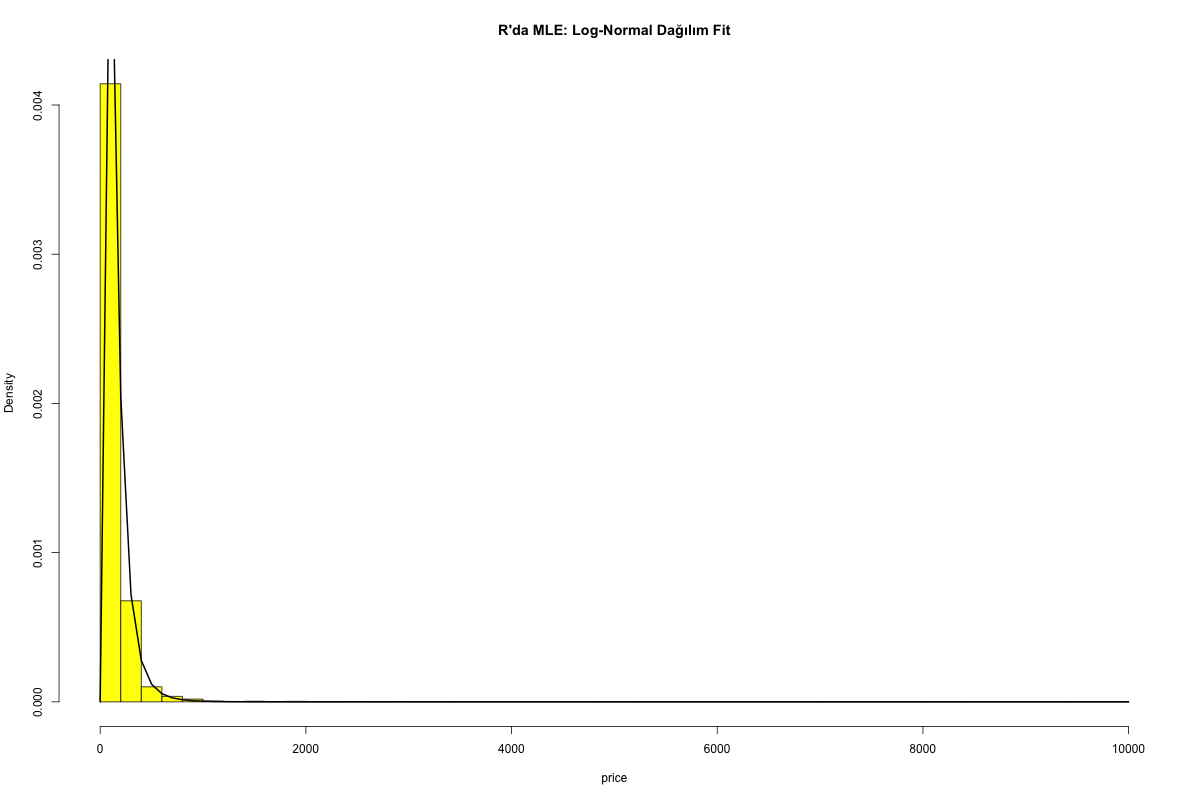

In [59]:
%%R -i airbnb -w 1200 -h 800

library(MASS)

price_clean <- airbnb$price[airbnb$price > 0 & !is.na(airbnb$price)]  # Sıfırdan büyük ve eksik değer olmayan fiyatları alalım

fit_sonuc <- fitdistr(price_clean, "lognormal")
print(fit_sonuc)

hist(price_clean, breaks=40, freq=FALSE, col="yellow", 
     main="R'da MLE: Log-Normal Dağılım Fit", xlab="price")
curve(dlnorm(x, fit_sonuc$estimate["meanlog"], fit_sonuc$estimate["sdlog"]), col="black", lwd=2, add=TRUE)

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 8.3–8.4 | MLE, MAP |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | Ders 18 | Maximum Likelihood tahmini |
| [StatQuest — Maximum Likelihood](https://www.youtube.com/watch?v=XepXtl9YKwc) | Video | Çok net görsel anlatım |
| [Seeing Theory](https://seeing-theory.brown.edu/frequentist-inference) | Frequentist Inference | İnteraktif |
| [Kaggle — Global Cancer Patients](https://www.kaggle.com/datasets/zahidmughal2343/global-cancer-patients-2015-2024) | Veri | global_cancer_patients kaynağı |
| [Kaggle — NYC Airbnb 2019](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) | Veri | AB_NYC_2019.csv kaynağı |
| [Kaggle — Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance) | Veri | insurance.csv kaynağı |